<a href="https://colab.research.google.com/github/sebakrys/data-science-bootcamp-A-Z/blob/main/33_s8_Transfer_Learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
%tensorflow_version 2.x
import numpy as np
import PIL.Image as Image
import tensorflow as tf
import tensorflow_hub as hub
from tensorflow.keras import layers
import matplotlib.pyplot as plt
print(f'Tensorflow version: {tf.__version__}')
print(f'Tensorflow Hub version: {hub.__version__}')
import tf_keras as tfk

Colab only includes TensorFlow 2.x; %tensorflow_version has no effect.
Tensorflow version: 2.17.1
Tensorflow Hub version: 0.16.1


#Załadowanie modelu

In [6]:
IMAGE_SHAPE = (224,224)
classifier = tfk.Sequential([
    hub.keras_layer.KerasLayer("https://www.kaggle.com/models/google/mobilenet-v2/TensorFlow2/140-224-classification/2",
                   input_shape=IMAGE_SHAPE+(3,))
])

##Załadowanie etykiet

In [7]:
labels_path = tf.keras.utils.get_file('ImageNetLabels.txt','https://storage.googleapis.com/download.tensorflow.org/data/ImageNetLabels.txt')
imagenet_labels = np.array(open(labels_path).read().splitlines())
imagenet_labels

10484/10484 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


array(['background', 'tench', 'goldfish', ..., 'bolete', 'ear',
       'toilet tissue'], dtype='<U30')

#Załadowanie obrazu


In [8]:
from google.colab import files
uploaded = files.upload()

Saving pobrane.png to pobrane.png


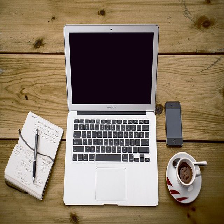

In [9]:
filename = list(uploaded.keys())[0]
img = Image.open(filename).resize(IMAGE_SHAPE)
img

##Predykcja na podstawie modelu

In [10]:
img_arr = np.array(img) / 255.0
img_arr = np.expand_dims(img_arr, axis=0)
result = classifier.predict(img_arr)
predicted_class = np.argmax(result[0], axis=-1)
predicted_class_name = imagenet_labels[predicted_class]
predicted_class_name

1/1 [==============================] - 2s 2s/step


'notebook'

##Wyświetlenie predykcji

(224, 224)
(1120, 1120)


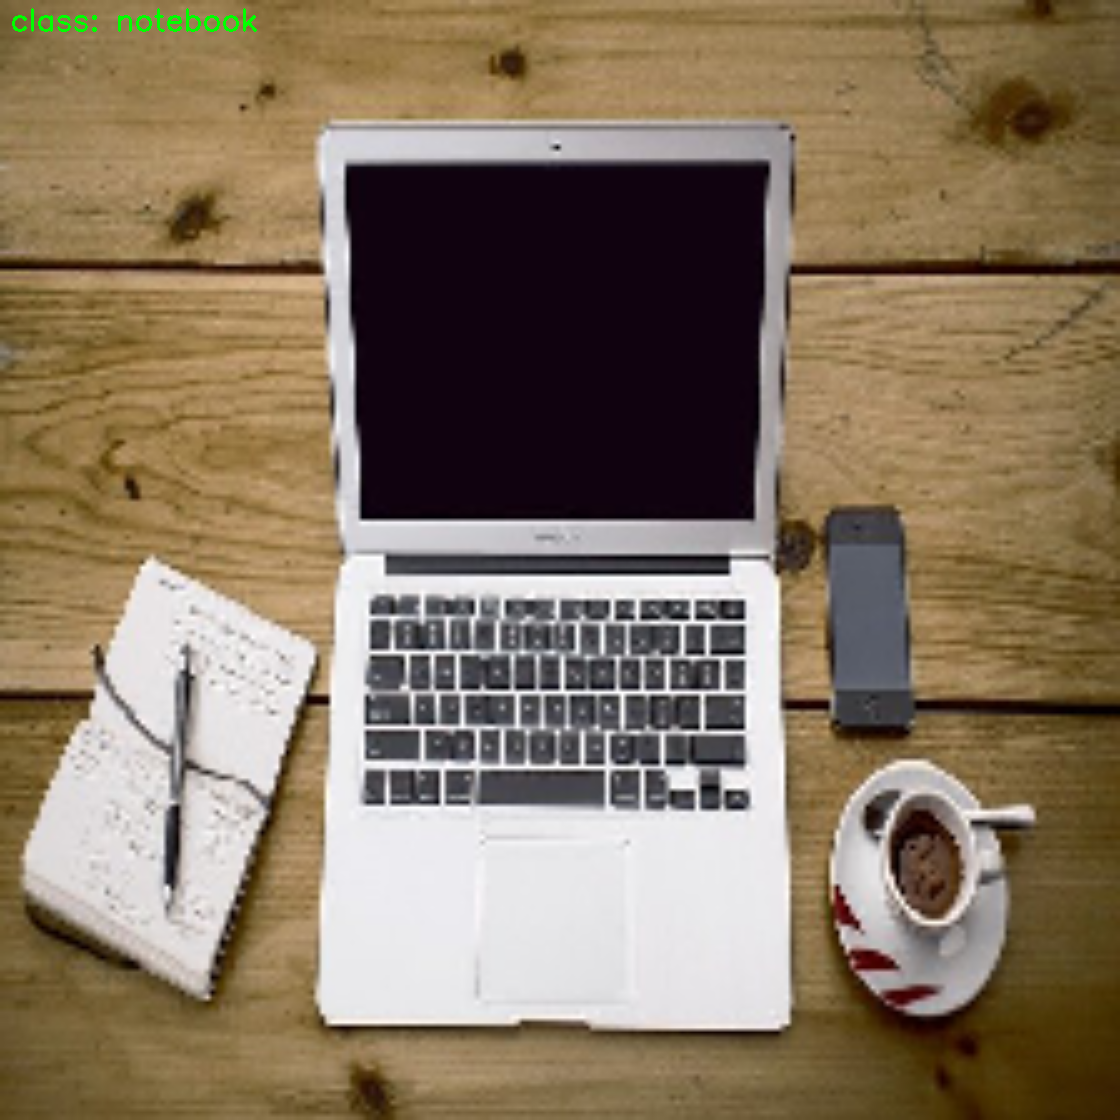

In [27]:
from google.colab.patches import cv2_imshow
import cv2

print((IMAGE_SHAPE))
print(tuple(i * 5 for i in IMAGE_SHAPE))

img = cv2.resize(cv2.imread(filename), tuple(i * 5 for i in IMAGE_SHAPE))
text = f'class: {predicted_class_name}'
img = cv2.putText(img=img, text=text, org=(10, 30), fontFace=cv2.FONT_HERSHEY_SIMPLEX, fontScale=1, color=(0, 255, 0), thickness=2)
cv2_imshow(img)